In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set up plotting style
plt.style.use('fivethirtyeight')

In [2]:
# Load our clean, split data
train_data = pd.read_csv("../data/processed/train_data.csv", 
                         index_col='Date', 
                         parse_dates=True)

test_data = pd.read_csv("../data/processed/test_data.csv", 
                        index_col='Date', 
                        parse_dates=True)

print(f"Loaded {len(train_data)} training points and {len(test_data)} test points.")
print(train_data.head())

Loaded 700 training points and 32 test points.
                   Close
Date                    
2023-11-01  35437.253906
2023-11-02  34938.242188
2023-11-03  34732.324219
2023-11-04  35082.195312
2023-11-05  35049.355469


In [3]:
# Define our model parameters
p, d, q = 1, 1, 1

# Create the ARIMA model
# We pass the original, non-differenced training data...
# ...and the model will handle the differencing (d=1) for us.
model = SARIMAX(train_data['Close'], 
                order=(p, d, q))

# Fit the model to the data
# This part can take a few seconds
print("Fitting the ARIMA(1, 1, 1) model...")
model_fit = model.fit(disp=False) # disp=False turns off verbose logging

# Print the model summary
print(model_fit.summary())

C:\Users\DELL\Desktop\folders\projects\stock prices\bitcoin_forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\folders\projects\stock prices\bitcoin_forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Fitting the ARIMA(1, 1, 1) model...
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  700
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -6266.790
Date:                Sat, 01 Nov 2025   AIC                          12539.581
Time:                        20:33:31   BIC                          12553.230
Sample:                    11-01-2023   HQIC                         12544.857
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1427      0.481     -0.297      0.767      -1.086       0.801
ma.L1          0.0737      0.481      0.153      0.878      -0.870       1.017
sigma2      3.60

In [4]:
# Define our baseline model parameters
p, d, q = 0, 1, 0

# Create the ARIMA(0, 1, 0) "Random Walk" model
baseline_model = SARIMAX(train_data['Close'], 
                         order=(p, d, q))

# Fit the model
print("Fitting the baseline ARIMA(0, 1, 0) model...")
baseline_fit = baseline_model.fit(disp=False)

# Print the model summary
print(baseline_fit.summary())

Fitting the baseline ARIMA(0, 1, 0) model...
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  700
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -6269.013
Date:                Sat, 01 Nov 2025   AIC                          12540.025
Time:                        20:37:57   BIC                          12544.575
Sample:                    11-01-2023   HQIC                         12541.784
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      3.605e+06   1.31e+05     27.487      0.000    3.35e+06    3.86e+06
Ljung-Box (L1) (Q):                   5.59   Jarque-Bera (JB):               156.77
Pr

C:\Users\DELL\Desktop\folders\projects\stock prices\bitcoin_forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\Desktop\folders\projects\stock prices\bitcoin_forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [5]:
# --- Generate Forecast ---

# How many steps do we want to predict?
# The number of days in our test_data
n_steps = len(test_data)

print(f"Forecasting {n_steps} steps (days) into the future...")

# Get the forecast from our (1,1,1) model
forecast_object = model_fit.get_forecast(steps=n_steps)

# Extract the predicted mean values
forecast_values = forecast_object.predicted_mean

# Get the confidence intervals (the "cone of uncertainty")
conf_int = forecast_object.conf_int(alpha=0.05) # 95% confidence interval

# --- Verification ---
print("\n--- Forecast ---")
print(forecast_values.head())

print("\n--- Confidence Intervals ---")
print(conf_int.head())

Forecasting 32 steps (days) into the future...

--- Forecast ---
2025-10-01    114090.517935
2025-10-02    114085.603507
2025-10-03    114086.304936
2025-10-04    114086.204822
2025-10-05    114086.219111
Freq: D, Name: predicted_mean, dtype: float64

--- Confidence Intervals ---
              lower Close    upper Close
2025-10-01  110369.985548  117811.050322
2025-10-02  109002.303960  119168.903055
2025-10-03  107914.373035  120258.236838
2025-10-04  106993.323976  121179.085668
2025-10-05  106178.602933  121993.835290


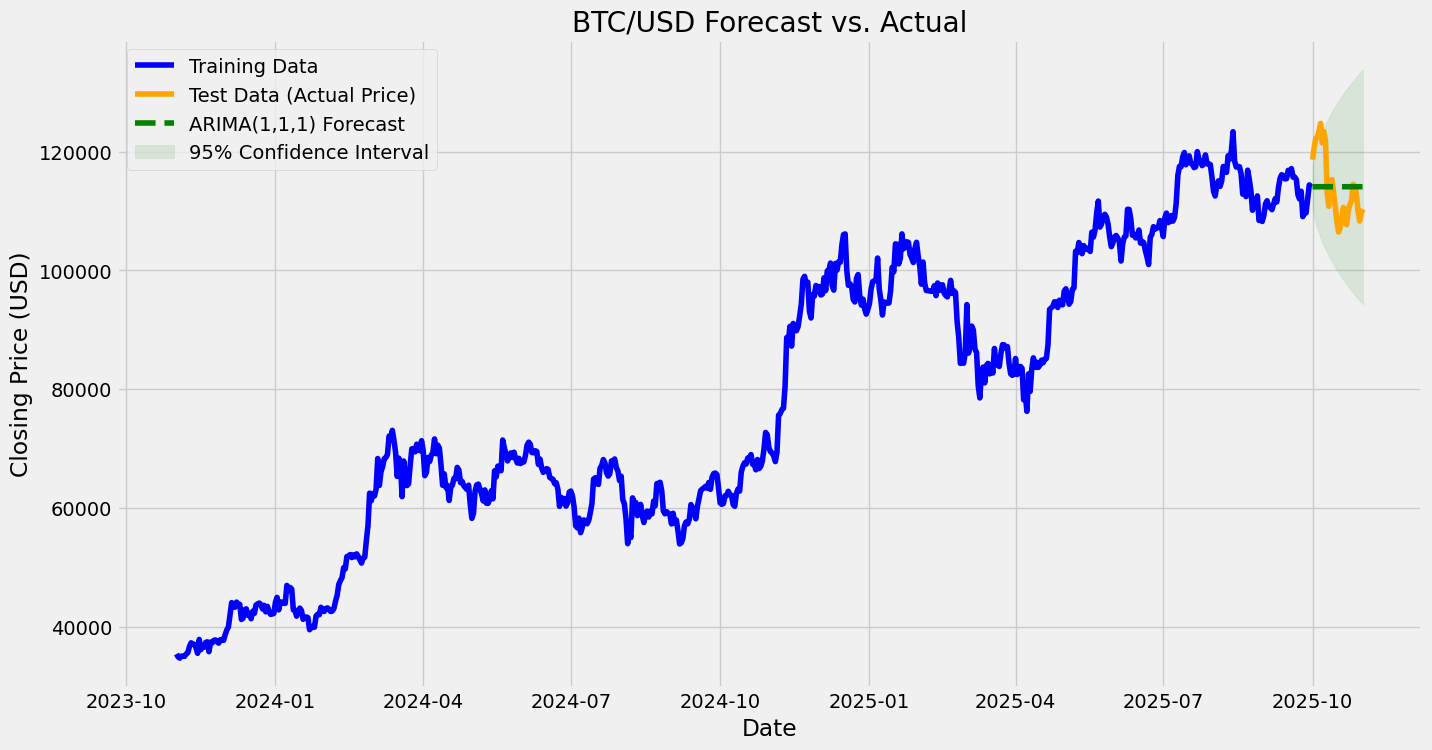

In [6]:
# --- Plot the Forecast vs. "Ground Truth" ---

plt.figure(figsize=(15, 8))

# Plot the training data
plt.plot(train_data['Close'], label='Training Data', color='blue')

# Plot the test data (the actual, real-world values)
plt.plot(test_data['Close'], label='Test Data (Actual Price)', color='orange')

# Plot our forecast
plt.plot(forecast_values, label='ARIMA(1,1,1) Forecast', color='green', linestyle='--')

# Plot the confidence interval
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0], # Lower bound
                 conf_int.iloc[:, 1], # Upper bound
                 color='green', 
                 alpha=0.1, 
                 label='95% Confidence Interval')

plt.title('BTC/USD Forecast vs. Actual')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend(loc='upper left')
plt.show()

In [7]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [8]:
# Calculate the Mean Squared Error
mse = mean_squared_error(test_data['Close'], forecast_values)

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print(f"--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Print RMSE as a percentage of the test data's average price
print(f"\nAverage Price in Test Set: {test_data['Close'].mean()}")
print(f"RMSE as % of Average Price: {(rmse / test_data['Close'].mean()) * 100:.2f}%")

--- Model Evaluation ---
Mean Squared Error (MSE): 31219062.333432246
Root Mean Squared Error (RMSE): 5587.402109516752

Average Price in Test Set: 113967.88305664062
RMSE as % of Average Price: 4.90%


### Efficient Market Hypothesis: 
The resulting forecast was a near-horizontal line. 
    This is a classic result, demonstrating that the ARIMA model has concluded the series behaves like a random walk,
where the best prediction for tomorrow's price is simply today's price.

***"The daily changes in Bitcoin are almost completely random (white noise). Therefore, the best possible guess for tomorrow's price is just today's price, and the price the day after, and so on."***

### The Benchmark:
By forecasting the hold-out test period (October 2025), we established our official benchmark to beat:

**RMSE**: 5,587.4

**Normalized RMSE**: 4.90%

The goal of the next notebook **(03_lstm_modeling.ipynb)** is to determine if a more complex deep learning (LSTM) model can find non-linear patterns that this classical model missed and achieve an RMSE lower than 5,587.4.